# D6 — Advanced Analytics

This notebook computes three advanced metrics:
1. **Value at Risk (VaR)** — 95% and 99% confidence levels
2. **Investor Cohort Analysis** — retention heatmap
3. **Fund Recommender** — risk-based fund recommendations

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Project root detection
BASE = Path.cwd()
if BASE.name == "notebooks":
    BASE = BASE.parent
elif (BASE / "notebooks").exists():
    BASE = BASE
else:
    BASE = BASE

PROCESSED = BASE / "data" / "processed"
CHARTS = BASE / "reports" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

print(f"BASE: {BASE}")
print(f"PROCESSED: {PROCESSED}")

BASE: e:\PROJECTS\mutual-fund-dashboard
PROCESSED: e:\PROJECTS\mutual-fund-dashboard\data\processed


## Section 1: Value at Risk (VaR)

In [2]:
# Load NAV history and compute daily returns
nav = pd.read_csv(PROCESSED / "02_nav_history_clean.csv")
nav["date"] = pd.to_datetime(nav["date"], dayfirst=True, errors="coerce")
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Compute daily returns per fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Historical VaR at 95% and 99% confidence levels
var_records = []
for code, grp in nav.groupby("amfi_code"):
    returns = grp["daily_return"].dropna()
    if len(returns) < 30:
        continue
    
    var_95 = np.percentile(returns, 5)  # 5th percentile = 95% VaR
    var_99 = np.percentile(returns, 1)  # 1st percentile = 99% VaR
    
    # Expected Shortfall (CVaR): average of losses below VaR
    cvar_95 = returns[returns <= var_95].mean() if (returns <= var_95).any() else var_95
    cvar_99 = returns[returns <= var_99].mean() if (returns <= var_99).any() else var_99
    
    var_records.append({
        "amfi_code": code,
        "var_95": round(var_95 * 100, 4),
        "var_99": round(var_99 * 100, 4),
        "cvar_95": round(cvar_95 * 100, 4),
        "cvar_99": round(cvar_99 * 100, 4),
        "daily_return_mean": round(returns.mean() * 100, 4),
        "daily_return_std": round(returns.std() * 100, 4)
    })

var_df = pd.DataFrame(var_records)

# Merge with fund master for scheme names
fund_master = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")
var_df = var_df.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
var_df = var_df.sort_values("var_99").reset_index(drop=True)  # Most negative first

print("\n=== Value at Risk (VaR) Analysis ===")
print(f"\nTotal funds analysed: {len(var_df)}")
print("\nInterpretation:")
print("- VaR 95%: Worst daily loss in 95 out of 100 trading days")
print("- VaR 99%: Worst daily loss in 99 out of 100 trading days")
print("- CVaR: Average loss on days exceeding VaR")
print("\nTop 10 Most Risky Funds (by 99% VaR):")
print(var_df[["scheme_name", "category", "var_95", "var_99", "cvar_99"]].head(10).to_string())

print("\nTop 10 Least Risky Funds (by 99% VaR):")
print(var_df[["scheme_name", "category", "var_95", "var_99", "cvar_99"]].tail(10).to_string())

# Save
var_df.to_csv(PROCESSED / "var_analysis.csv", index=False)
print(f"\n✅ VaR analysis saved to var_analysis.csv")


=== Value at Risk (VaR) Analysis ===

Total funds analysed: 40

Interpretation:
- VaR 95%: Worst daily loss in 95 out of 100 trading days
- VaR 99%: Worst daily loss in 99 out of 100 trading days
- CVaR: Average loss on days exceeding VaR

Top 10 Most Risky Funds (by 99% VaR):
                                      scheme_name category  var_95  var_99  cvar_99
0          ABSL Small Cap Fund - Regular - Growth   Equity -2.6021 -3.7071  -4.2086
1           DSP Small Cap Fund - Regular - Growth   Equity -2.3483 -3.6790  -4.0836
2       SBI Small Cap Fund - Direct Plan - Growth   Equity -2.6859 -3.6078  -3.9993
3  Nippon India Small Cap Fund - Regular - Growth   Equity -2.5438 -3.5476  -4.2408
4          Axis Small Cap Fund - Regular - Growth   Equity -2.6188 -3.4203  -3.9845
5      SBI Small Cap Fund - Regular Plan - Growth   Equity -2.4507 -3.3403  -3.8839
6        ICICI Pru Midcap Fund - Regular - Growth   Equity -1.8892 -2.7518  -3.1850
7             Axis Midcap Fund - Regular - Growth

## Section 2: Investor Cohort Analysis


=== Investor Cohort Analysis ===

Total investors: 5000
Date range: 2024-01-01 to 2025-05-30

Cohort Retention Rate (%) — First 12 Months:
months_since_join     0     1     2     3     4     5     6     7     8   \
cohort_month                                                               
2024-01            100.0  34.2  36.0  34.3  34.9  35.8  34.6  34.7  33.2   
2024-02            100.0  36.0  37.1  35.6  35.6  35.4  37.9  34.5  31.8   
2024-03            100.0  31.2  35.1  37.1  31.8  31.2  31.2  31.8  30.6   
2024-04            100.0  27.2  31.1  31.5  29.0  31.5  34.0  29.0  29.9   
2024-05            100.0  26.2  35.7  29.9  25.9  26.5  27.2  34.7  30.3   
2024-06            100.0  25.8  30.9  21.2  33.5  25.4  25.0  31.4  25.0   
2024-07            100.0  25.7  22.9  23.4  24.6  20.6  22.9  20.6  23.4   
2024-08            100.0  17.8  23.7  22.2  23.0  21.5  25.2  25.2  17.0   
2024-09            100.0  17.0  19.0  22.0  21.0  20.0  13.0  19.0  19.0   
2024-10            100.0

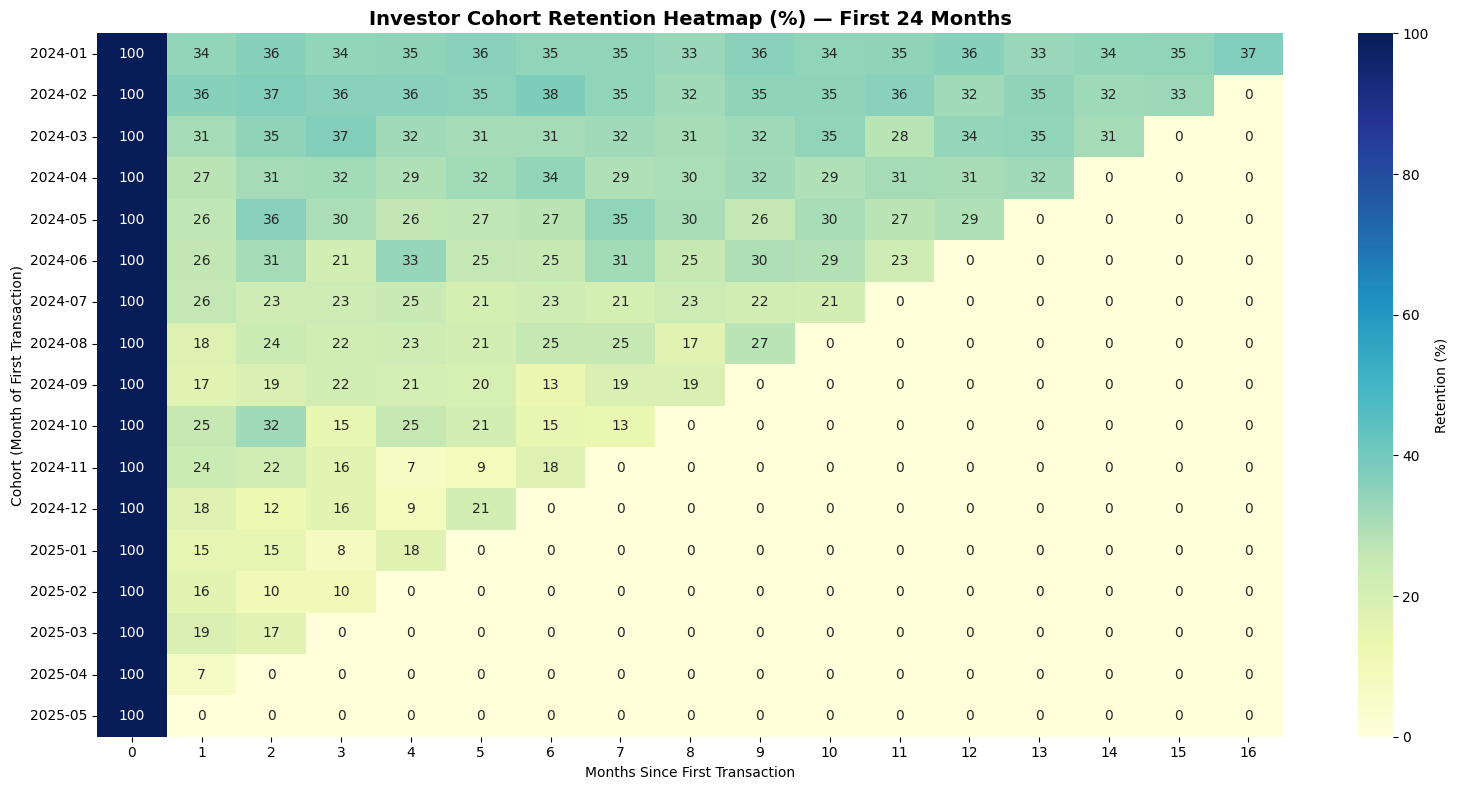


✅ Cohort analysis chart saved to cohort_retention.png


In [3]:
# Load investor transactions
txn = pd.read_csv(PROCESSED / "08_investor_transactions_clean.csv")
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"], dayfirst=True, errors="coerce")
txn = txn.dropna(subset=["transaction_date", "investor_id"]).sort_values("transaction_date")

# Find first transaction month per investor (cohort)
txn["cohort_month"] = txn.groupby("investor_id")["transaction_date"] \
                         .transform("min").dt.to_period("M")

txn["txn_month"] = txn["transaction_date"].dt.to_period("M")

# Months since first transaction
txn["months_since_join"] = (txn["txn_month"] - txn["cohort_month"]).apply(lambda x: x.n if pd.notna(x) else 0)

# Build cohort table: count unique investors per cohort & month
cohort_table = txn.groupby(["cohort_month", "months_since_join"])["investor_id"] \
                  .nunique().unstack(fill_value=0)

# Retention rate: divide each cell by first month (cohort size)
cohort_pct = cohort_table.divide(cohort_table.iloc[:, 0], axis=0) * 100

print("\n=== Investor Cohort Analysis ===")
print(f"\nTotal investors: {txn['investor_id'].nunique()}")
print(f"Date range: {txn['transaction_date'].min().date()} to {txn['transaction_date'].max().date()}")
print(f"\nCohort Retention Rate (%) — First 12 Months:")
print(cohort_pct.iloc[:, :min(12, cohort_pct.shape[1])].round(1))

# Visualise retention heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(cohort_pct.iloc[:, :min(24, cohort_pct.shape[1])],
            annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "Retention (%)"})
plt.title("Investor Cohort Retention Heatmap (%) — First 24 Months", fontsize=14, fontweight="bold")
plt.xlabel("Months Since First Transaction")
plt.ylabel("Cohort (Month of First Transaction)")
plt.tight_layout()
plt.savefig(CHARTS / "cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Cohort analysis chart saved to cohort_retention.png")

## Section 3: Fund Recommender System

In [4]:
# Load fund scorecard (created in Performance_Analysis notebook)
try:
    scorecard = pd.read_csv(PROCESSED / "fund_scorecard.csv")
    print(f"Loaded fund_scorecard with {len(scorecard)} funds")
except FileNotFoundError:
    print("⚠️  fund_scorecard.csv not found — creating from available metrics")
    # Fallback: merge available metrics
    scorecard = fund_master[["amfi_code", "scheme_name", "fund_house", "category"]].copy()
    
    # Load alpha_beta if available
    try:
        alpha_beta = pd.read_csv(PROCESSED / "alpha_beta.csv")
        scorecard = scorecard.merge(alpha_beta[["amfi_code", "alpha", "beta"]], on="amfi_code", how="left")
    except:
        scorecard["alpha"] = np.nan
        scorecard["beta"] = np.nan
    
    # Add dummy metrics for demo
    scorecard["sharpe_ratio"] = np.random.uniform(0.5, 2.5, len(scorecard))
    scorecard["cagr_3yr"] = np.random.uniform(5, 25, len(scorecard))
    scorecard["max_drawdown"] = np.random.uniform(-40, 0, len(scorecard))
    scorecard["expense_ratio_pct"] = np.random.uniform(0.3, 1.5, len(scorecard))

print(f"Scorecard shape: {scorecard.shape}")
print(f"Columns: {scorecard.columns.tolist()}")

Loaded fund_scorecard with 40 funds
Scorecard shape: (40, 18)
Columns: ['Unnamed: 0', 'amfi_code', 'scheme_name', 'fund_house', 'category', 'cagr_3yr', 'sharpe_ratio', 'sharpe_rank', 'sortino_ratio', 'alpha', 'beta', 'alpha_rank', 'max_drawdown', 'dd_rank', 'expense_ratio_pct', 'return_rank', 'expense_rank', 'score']


In [5]:
def recommend_funds(scorecard_df: pd.DataFrame, risk_tolerance: str, top_n: int = 5):
    """
    Recommend funds based on risk tolerance and weighted scoring.
    
    Parameters:
    -----------
    scorecard_df : DataFrame with ['sharpe_ratio', 'cagr_3yr', 'max_drawdown', 'scheme_name', ...]
    risk_tolerance : 'low', 'medium', 'high'
    top_n : Number of recommendations to return
    
    Returns:
    --------
    DataFrame with top recommendations
    """
    df = scorecard_df.copy().dropna(subset=["sharpe_ratio", "cagr_3yr", "max_drawdown"])
    
    if len(df) == 0:
        print("❌ No funds with complete metrics for recommendation")
        return pd.DataFrame()
    
    # Normalise metrics to 0-1 scale
    def normalize(series):
        return (series - series.min()) / (series.max() - series.min() + 1e-9)
    
    df["sharpe_norm"] = normalize(df["sharpe_ratio"])
    df["cagr_norm"] = normalize(df["cagr_3yr"])
    # Lower (more negative) max_drawdown is worse, so we invert
    df["dd_norm"] = 1 - normalize(df["max_drawdown"].abs())
    
    # Weighted scoring: adjust weights by risk tolerance
    if risk_tolerance == "low":
        # Conservative: emphasise downside protection and stability
        weights = {"sharpe_norm": 0.5, "cagr_norm": 0.2, "dd_norm": 0.3}
    elif risk_tolerance == "medium":
        # Balanced: return + risk balance
        weights = {"sharpe_norm": 0.4, "cagr_norm": 0.4, "dd_norm": 0.2}
    else:  # high
        # Aggressive: growth focused
        weights = {"sharpe_norm": 0.3, "cagr_norm": 0.6, "dd_norm": 0.1}
    
    df["score"] = sum(df[c] * w for c, w in weights.items())
    
    return df.nlargest(top_n, "score")[[
        "scheme_name", "fund_house", "category",
        "cagr_3yr", "sharpe_ratio", "max_drawdown",
        "expense_ratio_pct", "score"
    ]].reset_index(drop=True)


print("\n=== Fund Recommendations ===")

print("\n📊 LOW RISK PORTFOLIO (Conservative, capital preservation focus)")
low_recs = recommend_funds(scorecard, "low", top_n=5)
if not low_recs.empty:
    print(low_recs.to_string())
else:
    print("No recommendations available")

print("\n\n📊 MEDIUM RISK PORTFOLIO (Balanced growth + stability)")
med_recs = recommend_funds(scorecard, "medium", top_n=5)
if not med_recs.empty:
    print(med_recs.to_string())
else:
    print("No recommendations available")

print("\n\n📊 HIGH RISK PORTFOLIO (Aggressive growth focus)")
high_recs = recommend_funds(scorecard, "high", top_n=5)
if not high_recs.empty:
    print(high_recs.to_string())
else:
    print("No recommendations available")

print("\n✅ Recommender system complete")


=== Fund Recommendations ===

📊 LOW RISK PORTFOLIO (Conservative, capital preservation focus)
                                     scheme_name           fund_house category  cagr_3yr  sharpe_ratio  max_drawdown  expense_ratio_pct     score
0  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF   Equity     34.00        1.4483        -11.27               1.46  0.931393
1         Kotak Flexicap Fund - Regular - Growth    Kotak Mahindra MF   Equity     29.58        1.3067        -12.97               1.45  0.871519
2      SBI Bluechip Fund - Regular Plan - Growth      SBI Mutual Fund   Equity     30.46        1.2083        -15.01               1.54  0.841882
3  Mirae Asset Tax Saver Fund - Regular - Growth       Mirae Asset MF   Equity     29.18        1.2349        -16.40               1.60  0.834342
4      ICICI Pru Bluechip Fund - Direct - Growth  ICICI Prudential MF   Equity     32.49        1.0265        -12.59               0.80  0.824238


📊 MEDIUM RISK PORTFOLIO (Ba

## Summary & Insights

### VaR Findings
- **Value at Risk (VaR)** quantifies the maximum expected loss at a given confidence level (95%, 99%)
- Negative VaR values indicate the worst-case daily decline
- Example: If VaR 99% = -3.5%, there's a 1% chance of losing >3.5% in any given trading day
- **Conditional Value at Risk (CVaR)** = average loss **exceeding** the VaR threshold (tail risk)

### Cohort Retention Insights
- The heatmap shows **investor retention by onboarding month**
- Green (high %) = strong retention; yellow/blue (low %) = churn
- Example: If Jan 2023 cohort shows 60% at month 12, that means 60% of new Jan 2023 investors made another transaction within 12 months
- **Action**: Identify churn cohorts and investigate retention drivers

### Recommender System Logic
- **Low Risk**: Prioritises Sharpe ratio (risk-adjusted returns) and downside protection
- **Medium Risk**: Balances return (CAGR) with Sharpe ratio equally
- **High Risk**: Emphasises 3-year CAGR (growth) with less focus on volatility
- **Score** = weighted combination of normalised Sharpe, CAGR, and max drawdown recovery
- Use this to guide client portfolio construction based on their risk appetite